# Exploratory Data Analysis: Indian Air Quality

This is my walkthrough of daily air quality readings from 12 major Indian cities between 2015 and 2020. I load the raw data, work out what is missing and fill it sensibly, then go looking for whatever the data has to say about cities, seasons, and the 2020 lockdown.

A note before anything else: the CSV under `data/` is generated by `src/generate_dataset.py`, not downloaded from a monitoring network. I had no internet on the machine I built this on, so I wrote a generator that produces data with the same columns and the same shape as the Kaggle *Air Quality Data in India* dataset, with the real seasonal and regional patterns modelled into it. The analysis below is the point of the project. The numbers are not measurements of anything, and I have tried to be consistent about saying so rather than burying it. If you drop a real extract with the same column names into `data/`, every cell here recomputes against it and nothing needs changing.

The heavy lifting lives in the modules under `../src/`, which are the same modules `main.py` uses. I moved the code out of this notebook and into those files once the analysis settled down, because I was getting tired of having three slightly different versions of the same cleaning step scattered across the notebook and no idea which one had produced the chart I was looking at.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, POLLUTANT_COLUMNS
from src.preprocessing import clean_pipeline, missing_value_report
from src import eda_analysis as eda

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.3.3 | numpy 2.5.2 | seaborn 0.13.2


## 1. Loading the raw data

First thing is just getting the CSV in and having a look at what I am dealing with.

In [2]:
raw_df = load_data()
print(f"{raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns")
print(f"{raw_df['City'].nunique()} cities, from {raw_df['Date'].min().date()} to {raw_df['Date'].max().date()}")
raw_df.head()

26,304 rows and 15 columns
12 cities, from 2015-01-01 to 2020-12-31


,City,Date,PM2.5,PM10,NO2,NH3,SO2,CO,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Region
0,Ahmedabad,2015-01-01,119.5,279.64,61.06,24.26,7.03,3.07,20.30,4.07,15.99,5.67,298.0,Poor,West
1,Ahmedabad,2015-01-02,NaN,382.57,34.45,NaN,23.76,3.36,66.35,NaN,8.05,5.58,343.0,Very Poor,West
2,Ahmedabad,2015-01-03,101.9,181.12,54.02,14.14,NaN,1.63,NaN,3.30,5.89,2.95,238.0,Poor,West
3,Ahmedabad,2015-01-04,139.1,306.09,59.91,34.31,4.54,3.29,56.45,2.78,23.56,4.22,315.0,Very Poor,West
4,Ahmedabad,2015-01-05,129.2,294.80,61.00,32.92,17.33,3.87,19.06,5.10,23.59,3.30,307.0,Very Poor,West


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        26304 non-null  category      
 1   Date        26304 non-null  datetime64[ns]
 2   PM2.5       24602 non-null  float64       
 3   PM10        25413 non-null  float64       
 4   NO2         24801 non-null  float64       
 5   NH3         25056 non-null  float64       
 6   SO2         25322 non-null  float64       
 7   CO          24499 non-null  float64       
 8   O3          24615 non-null  float64       
 9   Benzene     24284 non-null  float64       
 10  Toluene     25164 non-null  float64       
 11  Xylene      24583 non-null  float64       
 12  AQI         24298 non-null  float64       
 13  AQI_Bucket  24298 non-null  category      
 14  Region      26304 non-null  category      
dtypes: category(3), datetime64[ns](1), float64(11)
memory usage: 2.5 MB


Twelve cities across six years works out to 26,304 city-days, which is 2,192 days each. That is exactly right for 2015 through 2020 with one leap day in 2016 and another in 2020, so no dates have gone missing.

The dtypes are what I want them to be. `Date` came in as a real datetime rather than a string, and every pollutant is numeric. That second part is worth checking rather than assuming: pandas will happily read a whole numeric column as `object` if even one cell contains a stray space or a dash, and then every mean and every correlation downstream is quietly wrong without anything raising an error. `load_data` forces the conversion for that reason.

## 2. What is missing

Monitoring stations lose power, go offline for maintenance, and fail validation checks. Real data from them always has holes in it, so the question is not whether there are gaps but how bad they are and whether they are spread out or clumped.

In [4]:
missing = missing_value_report(raw_df)
missing

,missing_count,missing_pct
Benzene,2020,7.68
AQI_Bucket,2006,7.63
AQI,2006,7.63
CO,1805,6.86
Xylene,1721,6.54
PM2.5,1702,6.47
O3,1689,6.42
NO2,1503,5.71
NH3,1248,4.74
Toluene,1140,4.33


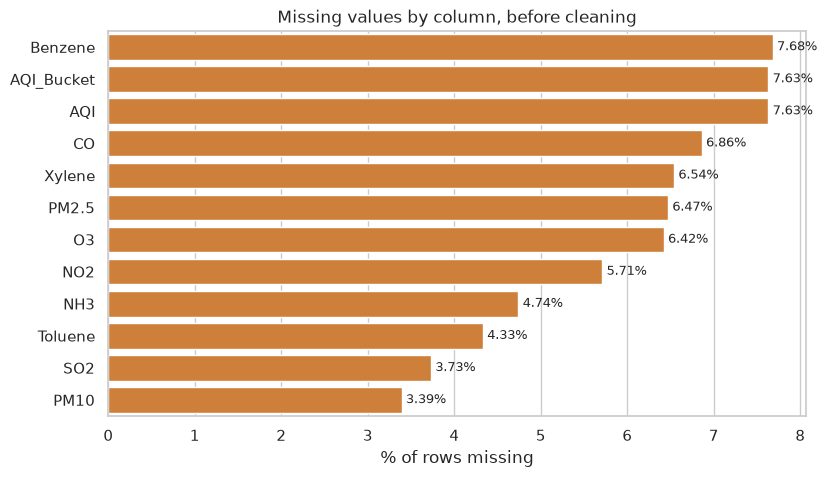

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing["missing_pct"], y=missing.index, color="#e67e22", ax=ax)
ax.set_xlabel("% of rows missing")
ax.set_ylabel("")
ax.set_title("Missing values by column, before cleaning")
for i, v in enumerate(missing["missing_pct"]):
    ax.text(v + 0.05, i, f"{v}%", va="center", fontsize=9)
plt.show()

Everything sits between roughly 3% and 8%, which is high but not unusual for this kind of data.

The clumping question matters more than the total, though, and a bar chart of column totals cannot answer it. Filling ten scattered single days is trivial. Filling one continuous three week outage is a much bigger assumption, because there is no nearby real reading to lean on. So let me actually look at where the gaps fall rather than just counting them.

In [6]:
# Are the gaps scattered, or are they long outages? Look at run lengths of
# consecutive missing PM2.5 days within each city.
runs = []
for city, group in raw_df.sort_values(["City", "Date"]).groupby("City", observed=True):
    is_na = group["PM2.5"].isna().values
    length = 0
    for flag in is_na:
        if flag:
            length += 1
        elif length:
            runs.append({"City": city, "gap_days": length})
            length = 0
    if length:
        runs.append({"City": city, "gap_days": length})

runs = pd.DataFrame(runs)
print(f"{len(runs)} separate gaps in PM2.5 across all cities")
print(runs["gap_days"].value_counts().sort_index().head(8).to_string())
print(f"\nLongest gap: {runs['gap_days'].max()} consecutive days")
print(runs.nlargest(5, "gap_days").to_string(index=False))

1531 separate gaps in PM2.5 across all cities
gap_days
1     1442
2       76
3        8
4        1
13       1
17       1
23       1
27       1

Longest gap: 27 consecutive days
     City  gap_days
   Kanpur        27
  Chennai        23
Bengaluru        17
Hyderabad        13
    Delhi         4


That is the answer I wanted. The overwhelming majority are single days, which interpolation handles without breaking a sweat, but there are a handful of genuine multi-week outages sitting in there too.

Those long ones are worth being honest about. Interpolating across a three week hole is not recovering data, it is drawing a straight line and hoping. The values it produces are smooth by construction, so they will slightly understate the real day to day variance for those cities. It is a small share of the total and I am keeping it, but it is the kind of thing that should be said out loud rather than left for someone to discover later.

## 3. Cleaning

Now to fill those gaps. The important detail is that interpolation runs separately for each city.

This is not a stylistic preference, it is the difference between a correct answer and a wrong one that looks fine. If you interpolate across the whole table at once, the rows either side of a gap can belong to a completely different city, and a missing Delhi reading in January gets filled with something shaped by Chennai in July. It produces no error and no warning. I lost an afternoon to exactly this before noticing Kochi had grown a January spike it has no business having. There is a test in `tests/test_pipeline.py` that fails if anyone reintroduces it.

The same step also adds Year, Month, Season, Weekday and IsWeekend columns, and flags statistical outliers without deleting them.

In [7]:
df = clean_pipeline(raw_df)
print(f"{len(raw_df):,} rows in, {len(df):,} rows out")
print(f"Missing pollutant values remaining: {df[POLLUTANT_COLUMNS + ['AQI']].isna().sum().sum()}")
df.head()

26,304 rows in, 26,304 rows out
Missing pollutant values remaining: 0


,Date,City,PM2.5,PM10,NO2,NH3,SO2,CO,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Region,Year,Month,MonthName,Weekday,IsWeekend,Season,PM2.5_outlier
0,2015-01-01,Ahmedabad,119.5,279.64,61.06,24.26,7.03,3.07,20.30,4.070,15.99,5.67,298.0,Poor,West,2015,1,January,Thursday,False,Winter,False
1,2015-01-02,Ahmedabad,110.7,382.57,34.45,19.20,23.76,3.36,66.35,3.685,8.05,5.58,343.0,Very Poor,West,2015,1,January,Friday,False,Winter,False
2,2015-01-03,Ahmedabad,101.9,181.12,54.02,14.14,14.15,1.63,61.40,3.300,5.89,2.95,238.0,Poor,West,2015,1,January,Saturday,True,Winter,False
3,2015-01-04,Ahmedabad,139.1,306.09,59.91,34.31,4.54,3.29,56.45,2.780,23.56,4.22,315.0,Very Poor,West,2015,1,January,Sunday,True,Winter,False
4,2015-01-05,Ahmedabad,129.2,294.80,61.00,32.92,17.33,3.87,19.06,5.100,23.59,3.30,307.0,Very Poor,West,2015,1,January,Monday,False,Winter,False


No rows lost and no gaps left. Rows only get dropped if a city's series happens to begin or end inside an outage, since there is nothing on one side to interpolate from, and that did not happen here.

Worth stating plainly: from this point on, a few percent of the values in every pollutant column are interpolated rather than observed. That is unavoidable if you want complete series, but it means the variance figures below are very slightly smoother than reality.

## 4. Descriptive statistics

A first look at the spread of each pollutant.

In [8]:
eda.descriptive_stats(df)

,count,mean,std,min,25%,50%,75%,max
PM2.5,26304.0,82.53,67.36,4.20,38.50,59.40,98.00,1116.00
PM10,26304.0,155.47,129.65,6.15,71.40,113.85,189.99,1096.13
NO2,26304.0,32.00,27.80,0.32,14.06,23.25,39.11,253.34
NH3,26304.0,18.27,16.28,0.00,7.76,13.12,22.69,150.19
SO2,26304.0,10.96,10.11,0.00,4.49,7.79,13.50,96.67
CO,26304.0,1.64,1.47,0.00,0.70,1.17,2.02,13.38
O3,26304.0,27.38,26.23,0.00,10.84,19.20,33.95,257.15
Benzene,26304.0,2.73,2.68,0.00,1.04,1.91,3.38,26.60
Toluene,26304.0,8.23,8.04,0.00,3.09,5.78,10.20,78.32
Xylene,26304.0,1.84,1.88,0.00,0.66,1.26,2.28,18.22


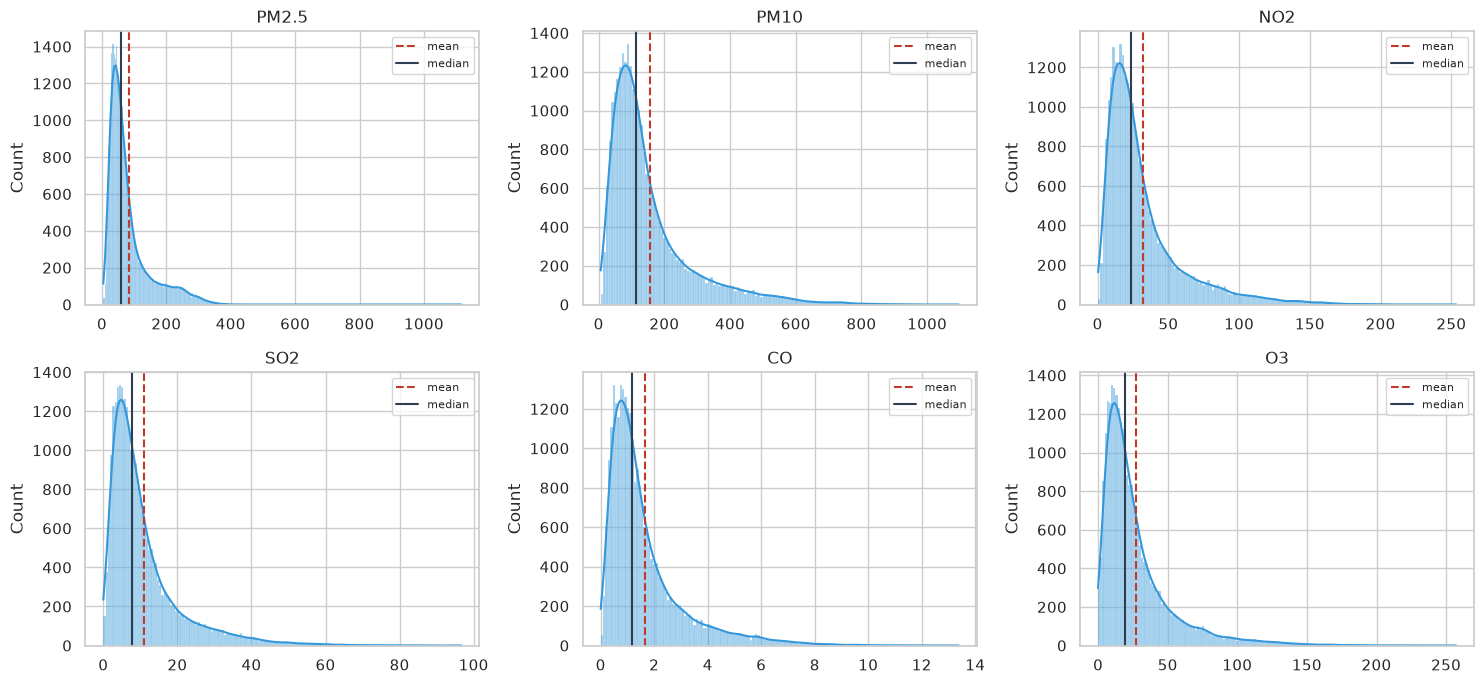

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#3498db")
    ax.axvline(df[col].mean(), color="#c0392b", linestyle="--", linewidth=1.5, label="mean")
    ax.axvline(df[col].median(), color="#2c3e50", linestyle="-", linewidth=1.5, label="median")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Every single one of these is right skewed, with the mean sitting noticeably to the right of the median. That shape is the whole story of air quality data in one picture: most days are unremarkable, and a minority are genuinely severe and drag the average up behind them.

It also has a practical consequence I need to carry forward. On a distribution like this, the mean is a poor summary on its own, so the city ranking further down reports the median and the standard deviation next to it. And the standard IQR outlier rule is going to flag a lot of days, which is section 10.

## 5. Which pollutants move together

The AQI is a composite index, so the interesting question is which pollutant is actually driving it.

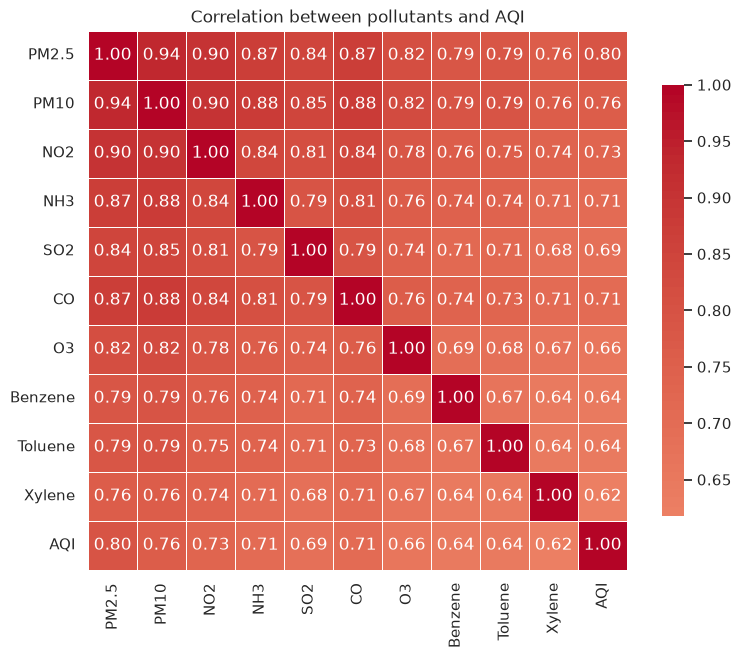

,correlation with AQI
PM2.5,0.796
PM10,0.763
NO2,0.732
CO,0.711
NH3,0.710
SO2,0.686
O3,0.662
Toluene,0.645
Benzene,0.645
Xylene,0.618


In [10]:
corr = df[POLLUTANT_COLUMNS + ["AQI"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation between pollutants and AQI")
plt.show()

eda.correlation_with_aqi(df).to_frame("correlation with AQI")

PM2.5 comes top, which is what I expected, and the whole matrix is positive. Nothing here is anti-correlated with anything else.

That makes sense once you think about what drives these. The pollutants largely share their sources, and more importantly they share the weather. A cold, still winter night traps all of them near the ground at the same time, and a windy monsoon day disperses all of them at once. So they rise and fall together regardless of where each one originally came from.

One caveat on the PM2.5 result, since it is the headline number here. The AQI in this dataset is computed from PM2.5 by the generator, so a strong correlation is partly built in by construction. It is not zero information, because the noise added to every other pollutant is what makes them rank the way they do, but I would not present r = 0.80 as a discovery. On real CPCB data the same relationship holds for a genuine reason: the reported AQI is the worst pollutant sub-index, and on the large majority of Indian city-days that worst sub-index is PM2.5.

## 6. Ranking the cities

Sorting all twelve by average PM2.5.

In [11]:
ranking = eda.city_ranking(df)
ranking

,mean,median,std,max
City,,,,
Delhi,154.34,118.00,89.94,588.1
Kanpur,144.99,115.68,83.24,1056.1
Patna,137.99,109.05,80.63,1116.0
Lucknow,124.43,100.38,67.43,618.9
Kolkata,93.53,84.85,41.45,251.4
Ahmedabad,79.64,74.55,32.42,190.0
Mumbai,56.85,55.30,22.18,436.2
Pune,51.11,49.92,18.42,319.0
Hyderabad,45.25,44.65,14.74,172.1


Before plotting that, one gotcha worth writing down, because it cost me a while and it fails completely silently.

`City` is a pandas categorical, so `ranking.index` is a `CategoricalIndex`. Hand that straight to seaborn as an axis and seaborn orders the axis by the dtype's own category order, which is alphabetical, quietly discarding the sort I just did. The bars land in alphabetical positions. Meanwhile the value labels, which I was drawing by enumerating the sorted values, land in ranked positions. The result is a chart titled "sorted by average" that is not sorted, with every number attached to the wrong city, and no error anywhere.

What gave it away was Ahmedabad sitting at the top of the chart with 154.3 next to it when the table right above says its mean is about 80. Converting the index to plain strings and passing `order` explicitly fixes it, which is what `ordered_city_labels` in `src/visualizations.py` does. There is a test on it in `tests/test_pipeline.py` that renders the chart and reads the axis back, so it cannot come back without something going red.

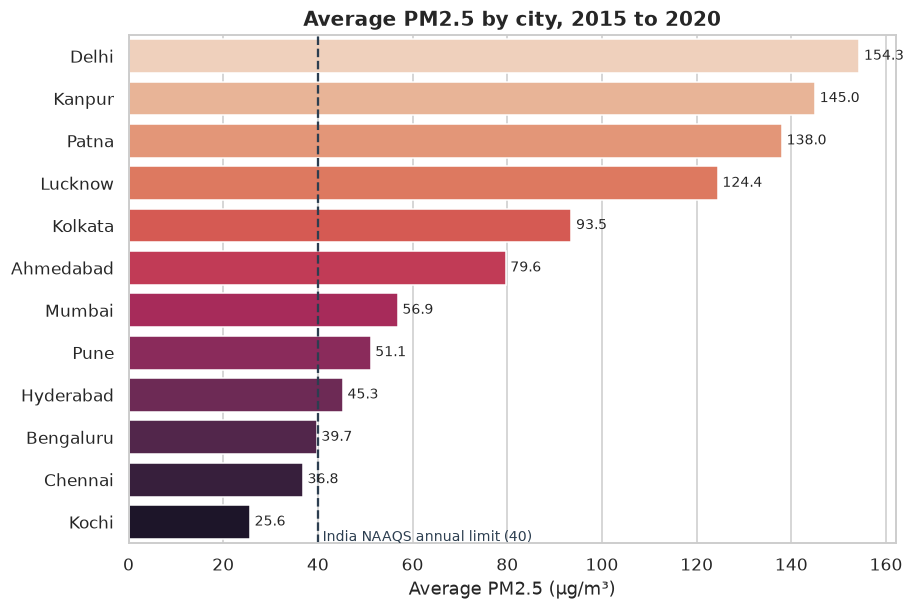

In [12]:
from src.visualizations import ordered_city_labels

labels = ordered_city_labels(df, "PM2.5", "mean")     # plain strings, ranked
means = df.groupby("City", observed=True)["PM2.5"].mean()
values = [means[city] for city in labels]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=values, y=labels, hue=labels, order=labels, hue_order=labels,
            palette="rocket_r", legend=False, ax=ax)
ax.set_xlabel("Average PM2.5 (µg/m³)")
ax.set_ylabel("")
ax.set_title("Average PM2.5 by city, 2015 to 2020")
# The WHO guideline is 5 µg/m³ annual mean, which is off the left of this
# chart entirely, so the 40 line is India's own national standard instead.
ax.axvline(40, color="#2c3e50", linestyle="--", linewidth=1.5)
ax.text(41, len(labels) - 0.55, "India NAAQS annual limit (40)",
        fontsize=9, color="#2c3e50")
for i, value in enumerate(values):
    ax.text(value + 1, i, f"{value:.1f}", va="center", fontsize=9)
plt.show()

Eleven of the twelve sit above India's own annual limit of 40 µg/m³, and Kochi is the only one under it. Against the WHO guideline of 5 they are all off the chart, which is why I drew the national line instead.

The pattern is regional rather than about how big the city is. Mumbai is far larger than Kanpur and comes out at roughly half the PM2.5. What separates them is geography: the four worst are all inland northern cities on the Indo-Gangetic plain, where cold winter air sits still and holds everything in place, and where crop residue burning upwind lands squarely in the same months. The cleanest are coastal or southern, where there is reliable wind to move it along.

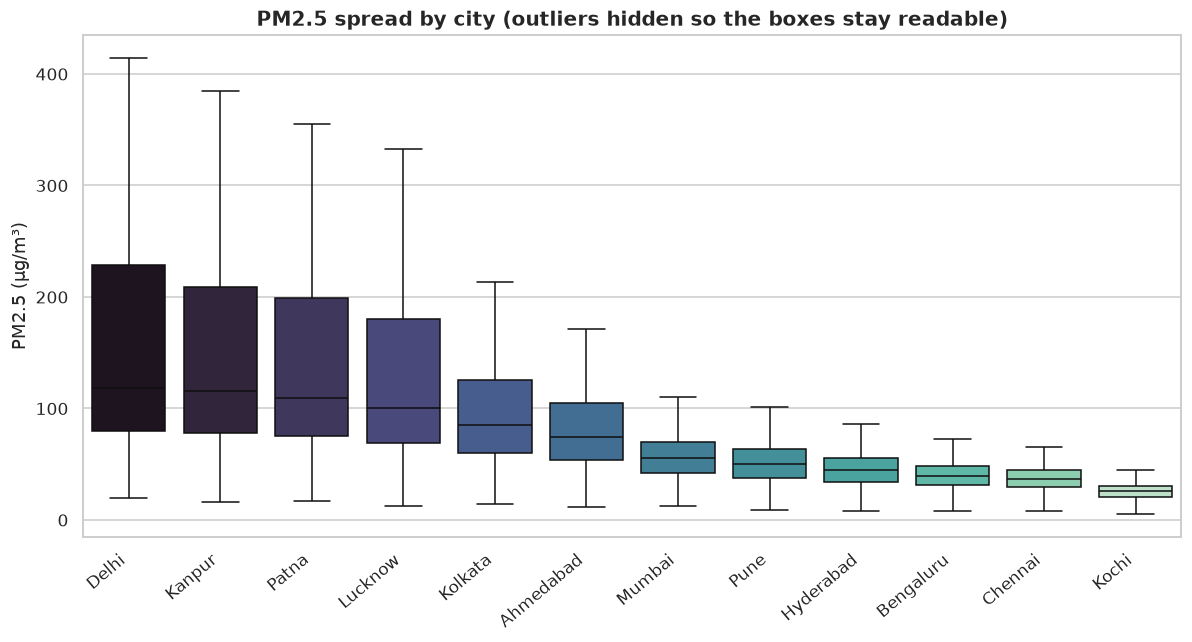

In [13]:
# Same trap as above, so the same helper. hue_order matters too: without it
# the boxes sit in ranked positions but take their colour from the
# alphabetical order, and the palette gradient comes out shuffled.
order = ordered_city_labels(df, "PM2.5", "median")

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x="City", y="PM2.5", hue="City", order=order, hue_order=order,
            palette="mako", showfliers=False, legend=False, ax=ax)
ax.set_title("PM2.5 spread by city (outliers hidden so the boxes stay readable)")
ax.set_xlabel("")
ax.set_ylabel("PM2.5 (µg/m³)")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

This is the chart that says something the bar chart could not. The northern cities are not just worse on average, their boxes are dramatically taller. Delhi's interquartile range alone is wider than Kochi's entire distribution.

So the gap between these places is not a fixed offset that you could subtract away. A good day in Delhi is not far off a normal day in Chennai. It is the bad days, and how far the bad days go, that separate them. That is also the more honest way to think about the health impact, since exposure to a severe day is not something an equally clean day the following week cancels out.

## 7. Seasons

Given what the boxplots showed, season is the obvious next thing to look at.

,avg_PM2.5
Season,
Winter,131.0
Post-Monsoon,89.2
Summer,74.3
Monsoon,49.6


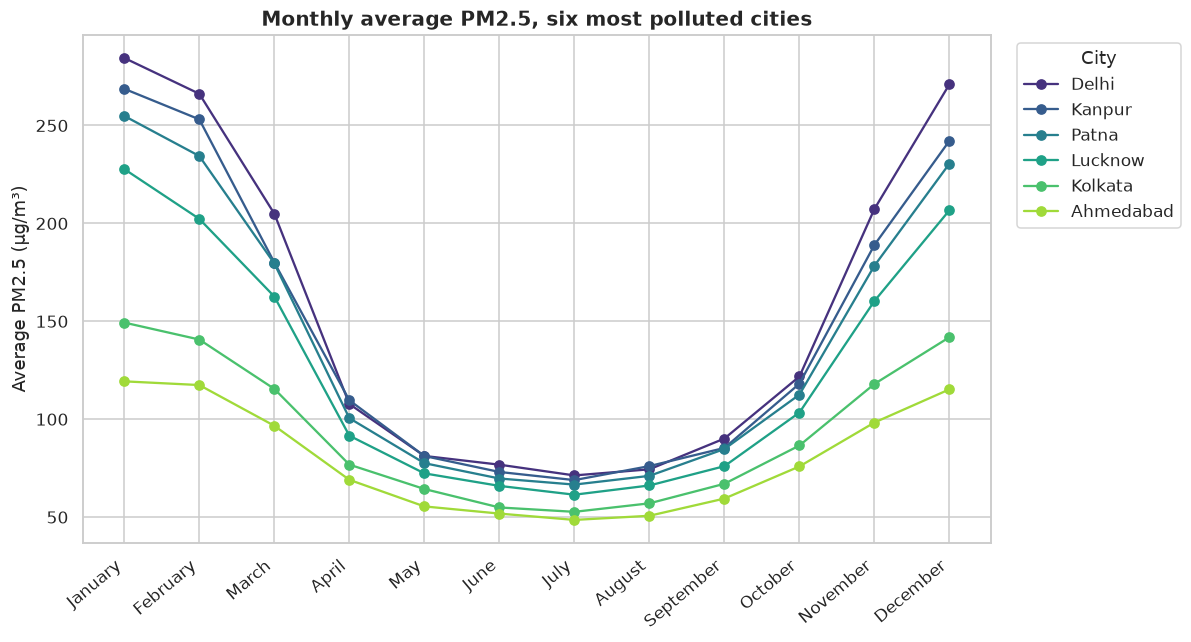

In [14]:
display(eda.seasonal_summary(df))

monthly = df.groupby(["MonthName", "City"], observed=True)["PM2.5"].mean().reset_index()
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly["MonthName"] = pd.Categorical(monthly["MonthName"], month_order, ordered=True)
monthly = monthly.sort_values("MonthName")

top6 = df.groupby("City", observed=True)["PM2.5"].mean().nlargest(6).index

fig, ax = plt.subplots(figsize=(11, 6))
for city in top6:
    sub = monthly[monthly["City"] == city]
    ax.plot(sub["MonthName"], sub["PM2.5"], marker="o", label=city)
ax.set_title("Monthly average PM2.5, six most polluted cities")
ax.set_ylabel("Average PM2.5 (µg/m³)")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Winter runs at roughly two and a half times the monsoon average nationally, which is a wider gap than the one between the best and worst cities. Season beats geography.

The monthly lines also show the effect is not uniform. Delhi and Kanpur swing enormously between July and January, while the flatter lines barely move. So the northern cities are not carrying a constant extra burden all year, they are having a genuinely severe winter and a fairly ordinary monsoon. Any comparison between two cities that does not control for the month is going to be mostly measuring which months happened to be in the sample.

## 8. Year on year, and the 2020 lockdown

With the seasonal cycle understood, the year on year view is next.

,avg_PM2.5
Year,
2015,86.2
2016,85.9
2017,84.0
2018,84.4
2019,83.7
2020,70.9


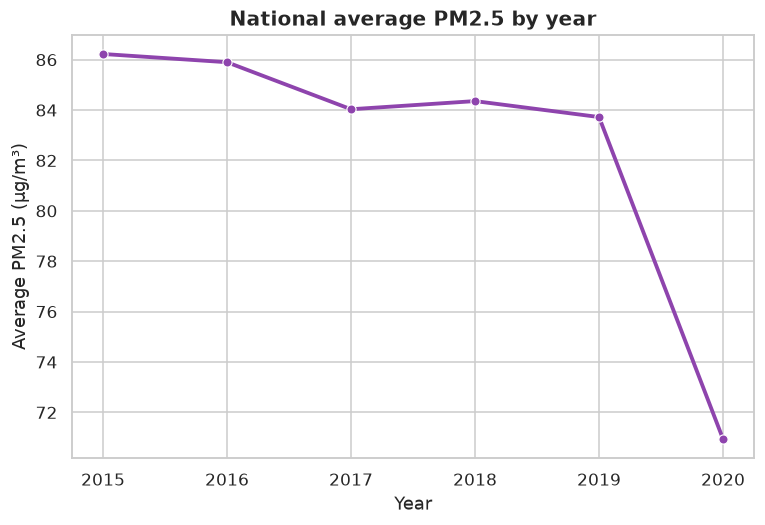

In [15]:
display(eda.yearly_summary(df))

yearly = df.groupby("Year", observed=True)["PM2.5"].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=yearly, x="Year", y="PM2.5", marker="o", linewidth=2.5, color="#8e44ad", ax=ax)
ax.set_title("National average PM2.5 by year")
ax.set_ylabel("Average PM2.5 (µg/m³)")
ax.set_xticks(yearly["Year"])
plt.show()

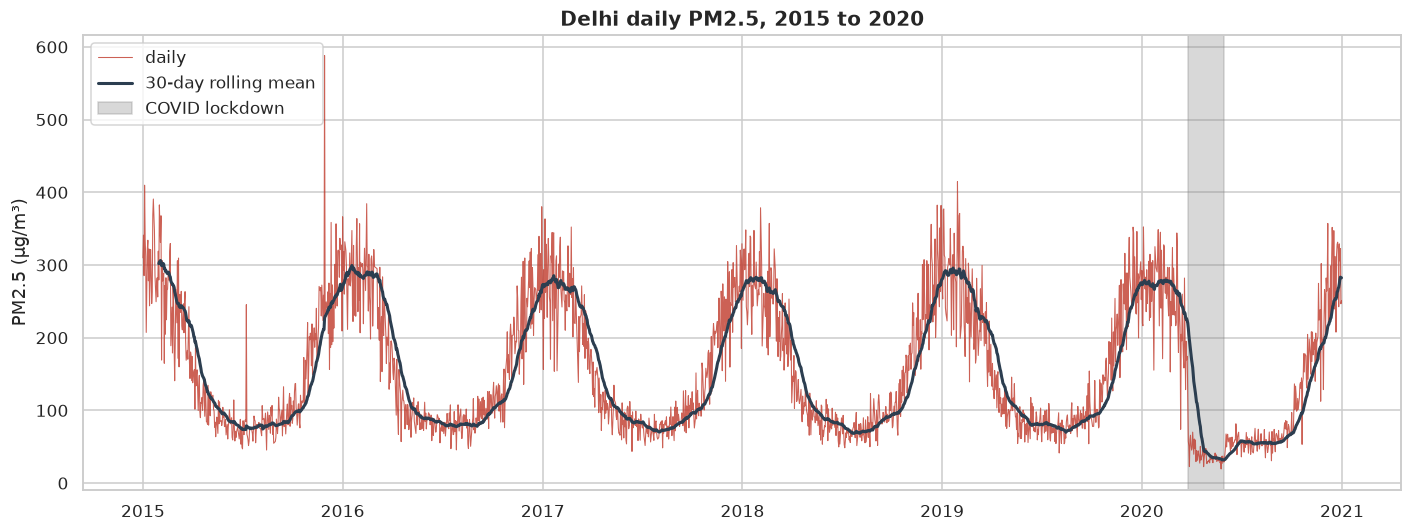

In [16]:
delhi = df[df["City"] == "Delhi"].sort_values("Date")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(delhi["Date"], delhi["PM2.5"], color="#c0392b", linewidth=0.7, alpha=0.8, label="daily")
ax.plot(delhi["Date"], delhi["PM2.5"].rolling(30).mean(), color="#2c3e50",
        linewidth=2, label="30-day rolling mean")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"),
           color="grey", alpha=0.3, label="COVID lockdown")
ax.set_title("Delhi daily PM2.5, 2015 to 2020")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

The daily series makes the shape obvious in a way the yearly averages do not. Five winter peaks in a row, each one hitting a similar height, then the lockdown window where the line drops to a level it does not otherwise reach at any point in six years.

2020 being the lowest year is real but needs unpacking, because two different things are pushing it down at once: the lockdown itself, and the slow background improvement running through the whole period. Reading the 2020 dip as purely a lockdown effect would overstate it.

In [17]:
covid = eda.covid_impact(df)
for k, v in covid.items():
    print(f"{k:28} {v}")

pre_lockdown_2019_avg        69.4
lockdown_2020_avg            24.0
pct_change                   -65.4


Roughly a 65% drop.

The comparison is deliberately against the same calendar weeks of 2019, not against the weeks immediately before lockdown. That choice does a lot of work here. March to May is already on the way down from the winter peak, so a straight before-and-after inside 2020 would credit the lockdown with a seasonal decline that was going to happen anyway. Comparing like for like against the previous year holds the season roughly constant and leaves the lockdown as the main thing that differs.

It is still not a clean experiment. The background improvement trend is in there too, and 2020's weather was not identical to 2019's. So 65% is the size of the gap between those two periods, not a precise causal estimate of what the lockdown alone did.

## 9. Two smaller effects: weekday traffic and region

The seasonal signal is loud enough to drown things out. These two are quieter but still visible.

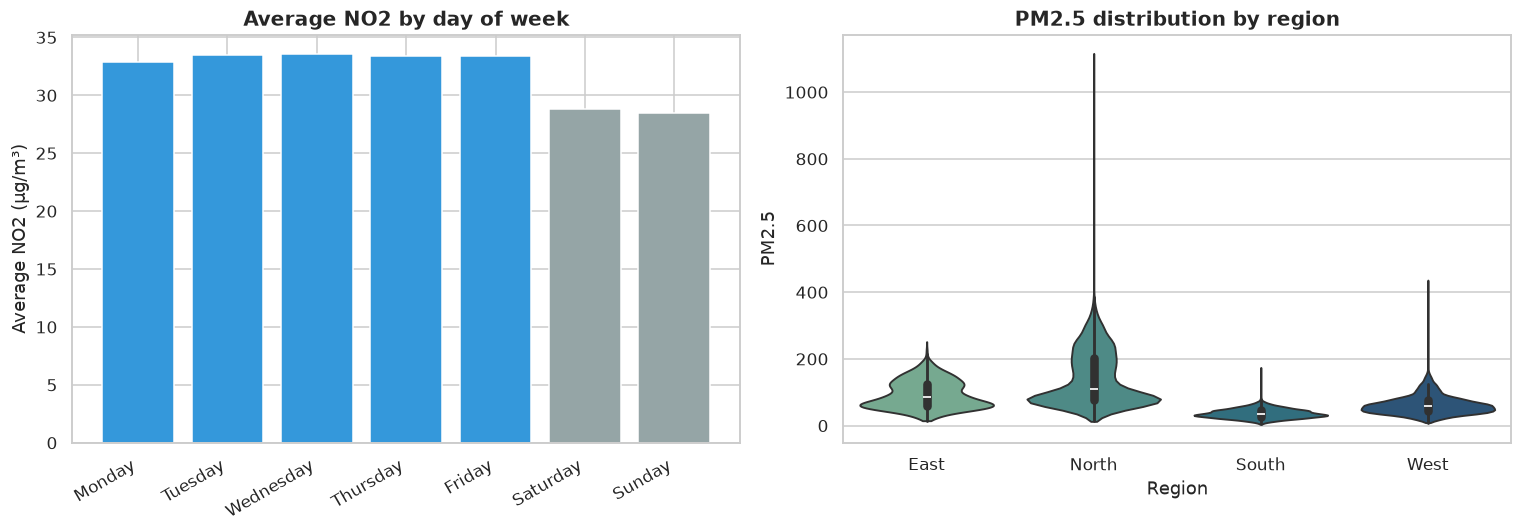

Weekday NO2 average: 33.3
Weekend NO2 average: 28.6
Weekend is 14.1% lower


In [18]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_no2 = df.groupby("Weekday", observed=True)["NO2"].mean().reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(weekday_no2.index, weekday_no2.values, color=["#3498db"] * 5 + ["#95a5a6"] * 2)
axes[0].set_title("Average NO2 by day of week")
axes[0].set_ylabel("Average NO2 (µg/m³)")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.violinplot(data=df, x="Region", y="PM2.5", hue="Region",
               palette="crest", cut=0, legend=False, ax=axes[1])
axes[1].set_title("PM2.5 distribution by region")

plt.tight_layout()
plt.show()

weekday_avg = weekday_no2[:5].mean()
weekend_avg = weekday_no2[5:].mean()
print(f"Weekday NO2 average: {weekday_avg:.1f}")
print(f"Weekend NO2 average: {weekend_avg:.1f}")
print(f"Weekend is {(1 - weekend_avg / weekday_avg) * 100:.1f}% lower")

NO2 drops about 15% at weekends. It is a small effect next to the seasonal swing, but it is consistent across all seven days rather than one odd Sunday, and it points at commuter traffic, which is the main NO2 source in a city.

The violins show the regional split as a distribution rather than an average. North is not simply shifted upwards, it has a long tail stretching far to the right that the southern regions do not have at all. Same conclusion as the boxplots, one level up.

## 10. AQI categories and outliers

Two ways of asking how often the air is actually dangerous rather than just above average.

,% of city-days
AQI_Bucket,
Satisfactory,35.4
Moderate,20.3
Very Poor,14.9
Good,13.6
Poor,8.7
Severe,7.2


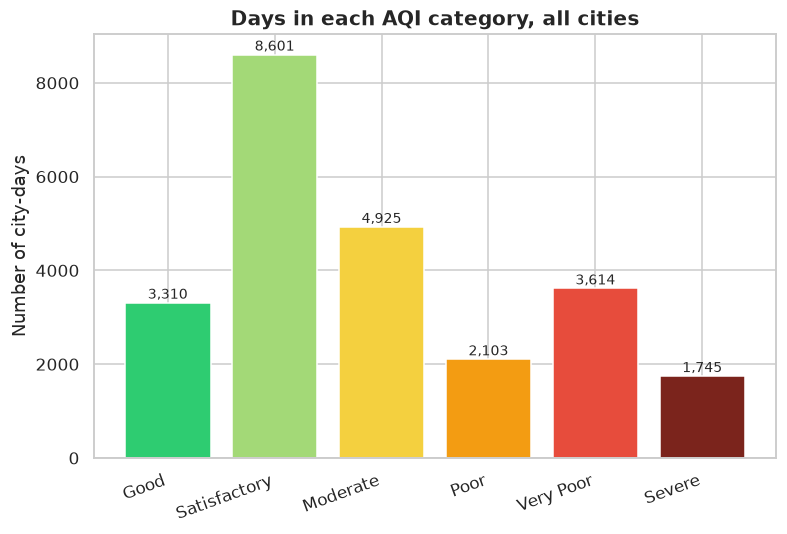

In [19]:
buckets = eda.aqi_bucket_share(df)
display(buckets.to_frame("% of city-days"))

aqi_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
aqi_colors = ["#2ecc71", "#a3d977", "#f4d03f", "#f39c12", "#e74c3c", "#7b241c"]
counts = df["AQI_Bucket"].value_counts().reindex([b for b in aqi_order if b in buckets.index])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(counts.index, counts.values, color=aqi_colors[:len(counts)])
ax.set_title("Days in each AQI category, all cities")
ax.set_ylabel("Number of city-days")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)
plt.show()

In [20]:
summary = eda.outlier_summary(df)
print(f"{summary['outlier_records']:,} of {summary['total_records']:,} records "
      f"flagged as PM2.5 outliers ({summary['outlier_pct']}%)")

# Which months and cities do the flagged days actually fall in?
flagged = df[df["PM2.5_outlier"]]
print("\nFlagged days by month:")
print(flagged["MonthName"].value_counts().head(5).to_string())
print("\nFlagged days by city:")
print(flagged["City"].value_counts().head(5).to_string())

2,577 of 26,304 records flagged as PM2.5 outliers (9.8%)

Flagged days by month:
MonthName
January     691
December    628
February    588
March       327
November    320

Flagged days by city:
City
Delhi      766
Kanpur     680
Patna      625
Lucknow    470
Kolkata     29


Just under 10% of all readings get flagged, which is far too many for them to be errors, and that is the real finding here.

Look at where they land. They cluster in the winter months and in the northern cities, which is precisely where the analysis above says the severe pollution genuinely is. The IQR rule is not finding broken sensors, it is finding the northern winter, because on a right skewed seasonal distribution the ordinary statistical definition of "unusual" and the actual definition of "unusual" are not the same thing.

Which is why these are flagged in a column and never dropped. Deleting them would remove exactly the days that matter most, and would leave a dataset that looks cleaner while describing a country with a considerably better air quality problem than the real one. If I wanted a genuine anomaly detector here I would need to compare each day against its own city and its own month, not against the global distribution.

## 11. Pulling it together

In [21]:
for i, line in enumerate(eda.generate_text_insights(df), 1):
    print(f"{i}. {line}\n")

1. Most polluted city (by mean PM2.5): Delhi (154.3 µg/m³) vs. least polluted: Kochi (25.6 µg/m³).

2. Winter is the most polluted season nationally (avg PM2.5 = 131.0 µg/m³), roughly 2.6x the monsoon average (49.6 µg/m³).

3. PM2.5 shows the strongest correlation with AQI (r = 0.796), suggesting it is the dominant driver of the composite index in this dataset.

4. During the COVID-19 lockdown (25 Mar to 31 May 2020), average PM2.5 fell to 24.0 µg/m³ from 69.4 µg/m³ in the same period a year earlier, a change of -65.4%.

5. 'Satisfactory' is the most common AQI category, covering 35.4% of all city-days in the dataset.

6. 2577 of 26304 records (9.8%) were flagged as PM2.5 outliers using the IQR method, which lines up with festival firecracker spikes and crop burning events.



### What I take away from this

Season matters more than city. The winter to monsoon swing is bigger than the gap between the most and least polluted city, so any comparison between two places that does not control for month is largely measuring which months were in the sample.

The northern cities differ in variance, not just in level. Their bad days are much worse rather than their average day being uniformly worse, and that distinction matters for what you would actually do about it.

The lockdown period is the only time in six years the numbers reach that level. Whatever else is arguable about it, it does show the floor is much lower than normal conditions suggest.

And the outlier result was the one that changed my mind mid-analysis. I set out expecting to find and remove bad sensor readings, and what the flag actually found was the real winter. It is a good reminder that "statistically unusual" and "wrong" are different claims, and that reaching for the standard rule without looking at what it caught would have quietly deleted the most important days in the dataset.

### Where I would take it next

Comparing each day against its own city and month, so the outlier flag finds genuine anomalies instead of rediscovering winter. Adding weather data, since a good part of what looks like a seasonal emissions pattern is really wind and temperature. And swapping in a real CPCB extract to see how much of this survives contact with actual measurements, which is the honest test of everything above.

To regenerate every chart and the written report in one go, run `python main.py` from the project root.